# *N. glabratus* Thermal Performance Curve Analysis

Here we fit thermal performance curves (TPCs) for N. glabratus populations that were
experimentally evolved at 40°C or 35°C, plus the ancestral strain (fRS585), 
assayed at 25°C, 35°C, 38°C, 41°C, and 42°C.

Input: Table_S1.xlsx

Pipeline:
1. Parse OD600 data and strain key
2. Estimate growth rates for each well (lag-corrected 3-parameter logistic)
3. Fit Sharpe–Schoolfield High (1981) TPCs per strain (multistart, 500 starts)
4. Linear mixed-effects model on raw growth rates
5. Figures: Raw growth curves, SSH fits, TPCs, Topt vs TPR scatterplot
6. Export CSVs

## Imports and configuration

In [5]:
import datetime
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import curve_fit
from openpyxl import load_workbook
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

#Directories
DATA_PATH = './Table_S1.xlsx'
OUT       = Path('Processed_Outputs')
OUT.mkdir(exist_ok=True)

#Plots formatting
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.weight':       'bold',
    'axes.labelweight':  'bold',
    'axes.titleweight':  'bold',
    'figure.dpi':        150,
})

EVO_COLORS = {
    '40°C Evolved': '#FA3208',
    '35°C Evolved': '#0E63FF',
    'Ancestor':      '#000000',
}

#Sharpe–Schoolfield constants
K_B    = 8.617333e-5   #Boltzmann constant (eV K⁻¹)
TREF_K = 288.15        #Reference temperature: 15°C
CTMAX_CAP = 50.0       #Cap CT_max for strains whose curve never reaches zero

## Parse strain key and OD600 data

In [11]:
#Well-strain mapping from 'Key' sheet in the .xlsx input
wb = load_workbook(DATA_PATH, read_only=True)
ws_key    = wb['Key']
key_rows  = list(ws_key.iter_rows(values_only=True))
well_to_strain = {1: {}, 2: {}, 3: {}}

for row in key_rows[6:]:
    if row[0] is None: continue
    for block_idx, (loc_col, strain_col) in enumerate([(0,1),(2,3),(4,5)], start=1):
        loc    = row[loc_col]
        strain = row[strain_col]
        if loc and strain and strain != 'Strain Dropped':
            for well in str(loc).split(','):
                well_to_strain[block_idx][well.strip()] = strain

print('Well→strain mappings:', {b: len(d) for b,d in well_to_strain.items()})


#OD600 time-series from temperature sheets
def time_to_hours(t):
    if isinstance(t, datetime.time):
        return t.hour + t.minute/60 + t.second/3600
    elif isinstance(t, datetime.timedelta):
        return t.total_seconds()/3600
    return np.nan


def parse_temp_sheet(ws, temp_label, well_to_strain):
    rows   = list(ws.iter_rows(values_only=True))
    records = []
    block_starts = [(i, int(row[0].split()[1]))
                    for i, row in enumerate(rows)
                    if isinstance(row[0], str) and row[0].startswith('BLOCK')]
    for bi, (start_idx, block_num) in enumerate(block_starts):
        header   = rows[start_idx + 1]
        well_cols = {ci: header[ci] for ci in range(2, len(header)) if header[ci]}
        end_idx  = block_starts[bi+1][0] if bi+1 < len(block_starts) else len(rows)
        for row in rows[start_idx+2:end_idx]:
            if row[0] is None: continue
            t_h = time_to_hours(row[0])
            if np.isnan(t_h): continue
            for ci, well in well_cols.items():
                od = row[ci] if ci < len(row) else None
                if od is None or not isinstance(od, (int, float)): continue
                records.append({'block': block_num, 'well': well,
                                'strain': well_to_strain[block_num].get(well),
                                'time_h': t_h, 'OD': float(od), 'temp': temp_label})
    return pd.DataFrame(records)

temp_dfs = []
for sheet, label in [('25C',25),('35C',35),('38C',38),('41C',41),('42C',42)]:
    df_t = parse_temp_sheet(wb[sheet], label, well_to_strain)
    temp_dfs.append(df_t)
    print(f'  {sheet}: {df_t.shape[0]:,} rows')

df_all = pd.concat(temp_dfs, ignore_index=True)
df_all = df_all.dropna(subset=['strain']).copy()
df_all['OD'] = df_all['OD'].clip(lower=1e-4)

# Assign evolution history
def assign_evo(strain):
    if strain.startswith('40_'):   return '40°C Evolved'
    if strain.startswith('35_'):   return '35°C Evolved'
    if 'fRS585' in strain:         return 'Ancestor'
    return 'Other'

df_all['evo_history'] = df_all['strain'].apply(assign_evo)

Well→strain mappings: {1: 39, 2: 39, 3: 39}
  25C: 27,936 rows
  35C: 27,936 rows
  38C: 27,936 rows
  41C: 27,936 rows
  42C: 27,936 rows


## Plot the raw OD600 growth curves

One averaged line per population by assay temperature. This is partly a
visual QC check before estimating growth rate.

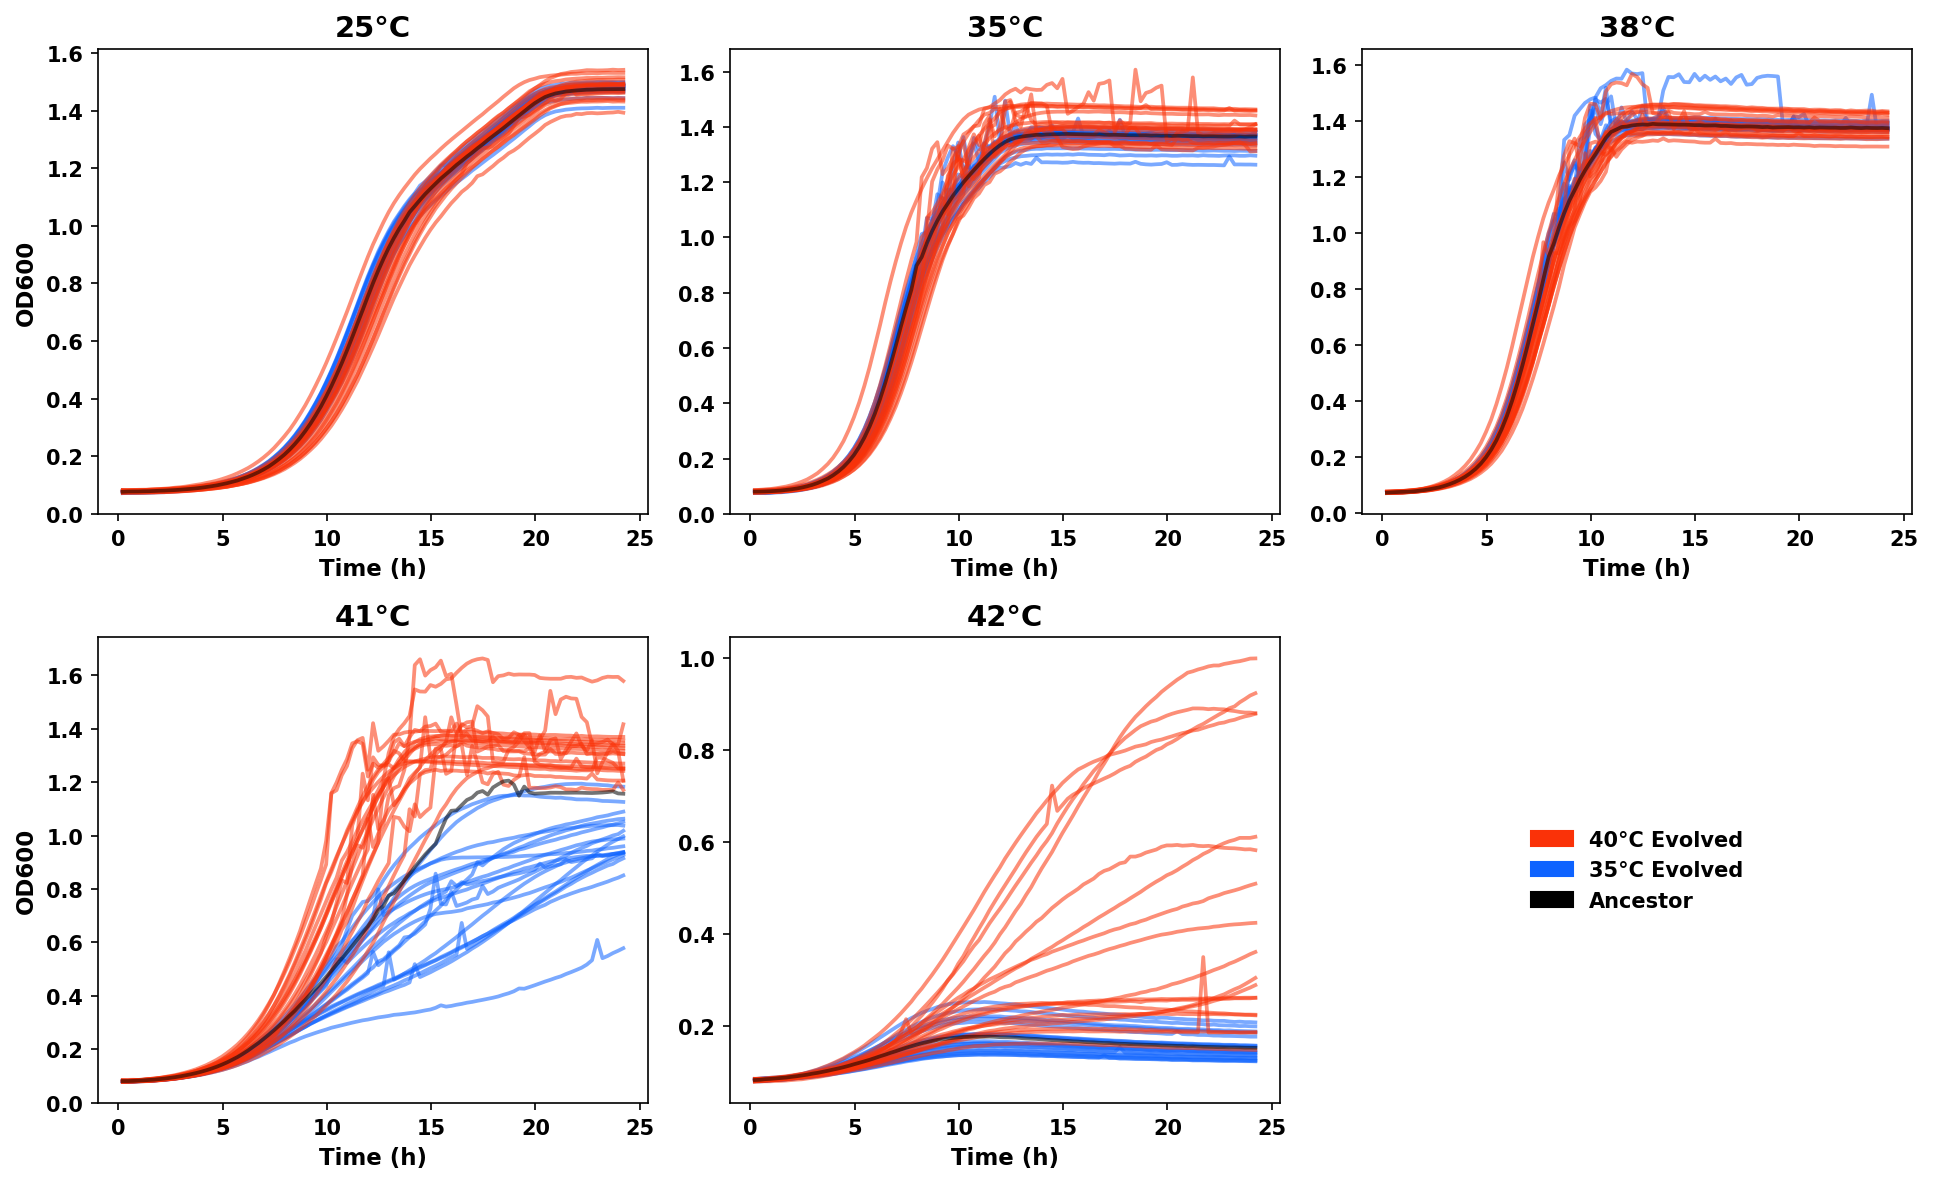

In [21]:
PRIMARY = ['40°C Evolved', '35°C Evolved', 'Ancestor']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

for ax, temp in zip(axes_flat[:5], [25, 35, 38, 41, 42]):
    sub = df_all[(df_all['temp']==temp) & (df_all['evo_history'].isin(PRIMARY))]
    sub_avg = sub.groupby(['strain','evo_history','time_h'])['OD'].mean().reset_index()
    for (strain, evo), grp in sub_avg.groupby(['strain','evo_history']):
        ax.plot(grp['time_h'], grp['OD'],
                color=EVO_COLORS.get(evo,'#AAAAAA'), alpha=0.55, lw=1.8)
    ax.set_title(f'{temp}°C', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (h)', fontsize=11, fontweight='bold')
    if temp in (25, 41):
        ax.set_ylabel('OD600', fontsize=11, fontweight='bold')

#Legend in the place of a 6th panel
handles = [mpatches.Patch(color=EVO_COLORS[g], label=g) for g in PRIMARY]
axes_flat[-1].legend(handles=handles, loc='center', fontsize=10, frameon=False)
axes_flat[-1].axis('off')

plt.tight_layout()
plt.savefig(OUT / 'qc_raw_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## Estimate Growth Rates

Fits a 3-parameter logistic to each well's OD600 time-series:

$$OD(t) = \frac{K}{1 + e^{-r(t - t_{mid})}}$$

Maximum instantaneous growth rate: $\mu = r \cdot K / 4 \times 24$ (day⁻¹).

This is equivalent to `growthTools::get.growth.rate(methods=c('sat','flr'))`, where
fitting the full sigmoid accounts for lag phase. This also will fall back to sliding-window
max slope on log(OD) if the logistic fit fails.

In [25]:
def fit_growth_logistic(time_h, OD, min_points=6):
    #Defines the 3-parameter logistic curve used for fitting
    #K is the carrying capacity (max OD), r is the growth rate, and t_mid is the inflection point (where growth is fastest)
    def logistic3(t, K, r, t_mid):
        return K / (1 + np.exp(-r * (t - t_mid)))
    
    #If there were, for some reason, not enough time points to fit reliably, then exit here. This should never be the case, though
    n = len(time_h)
    if n < min_points:
        return np.nan, np.nan, np.nan

    #These are the starting points (reasonable guesses for each parameter)
    OD_max, OD_min = np.max(OD), np.min(OD)
    t_range = time_h[-1] - time_h[0]
    grad    = np.gradient(OD, time_h)
    K0      = OD_max * 1.05
    #This is the time at which OD600 was rising the quickest
    t_mid0  = time_h[np.argmax(grad)]
    #This is an estimated growth rate based on that peak
    r0      = max(4 * np.max(grad) / K0, 0.05)

    #This tries to fit the logistic curve using Scipy's curve_fit
    try:
        popt, _ = curve_fit(
            logistic3, time_h, OD,
            p0=[K0, r0, t_mid0],
            bounds=([OD_min, 0.005, -t_range], [OD_max*3, 20.0, time_h[-1]+t_range]),
            maxfev=10000)
        
        #Kind of a sanity check to make sure everything is plausible (growth rate must be positive and carrying capacity can't be lower than the smallest OD600 observed)
        K_fit, r_fit, t_mid_fit = popt
        if K_fit < OD_min or r_fit <= 0:
            raise ValueError('Implausible params')
        #Generates predicted OD600 values based on the fit curve, then computes R-squared
        pred   = logistic3(time_h, *popt)
        ss_res = np.sum((OD - pred)**2)
        ss_tot = np.sum((OD - OD.mean())**2)
        r2     = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        #Spits out the maximum instantaneous growth rate (multiplied by 24 to go from per-hour to per-day), as well as R-squared values, and lag time (hours)
        return r_fit * K_fit / 4 * 24, r2, max(t_mid_fit - 2.0/r_fit, 0.0)
    except Exception:
        pass

    #Fallback: sliding-window max slope
    ln_OD = np.log(np.clip(OD, 1e-6, None))
    best_mu, best_r2 = np.nan, np.nan
    for start in range(n - 4):
        for end in range(start + 4, n + 1):
            x = time_h[start:end]; y = ln_OD[start:end]
            if np.ptp(x) == 0: continue
            slope, _, r, _, _ = stats.linregress(x, y)
            if slope > best_mu or np.isnan(best_mu):
                best_mu, best_r2 = slope * 24, r**2
    return best_mu, best_r2, np.nan

records = []
#Run the fitting function on each strain
for (strain, evo, block, well, temp), grp in df_all.groupby(
        ['strain','evo_history','block','well','temp']):
    grp_s = grp.sort_values('time_h')
    mu, r2, lag = fit_growth_logistic(grp_s['time_h'].values, grp_s['OD'].values)
    records.append({'strain':strain,'evo_history':evo,'block':block,
                    'well':well,'temp':temp,'mu':mu,'R2':r2,'lag_h':lag})

#Building and summarizing the results output
growth_rates = pd.DataFrame(records)
print(f'Growth rates estimated: {len(growth_rates):,} wells')
print(growth_rates.groupby('temp')['mu'].describe().round(3))

#Average wells → one value per strain × block × temperature
mu_mean = (
    growth_rates
    .groupby(['strain','evo_history','block','temp'])
    .agg(mu=('mu','mean'), n_wells=('mu','count'))
    .reset_index()
)
print(f'\nmu_mean rows: {len(mu_mean)}')

Growth rates estimated: 585 wells
      count   mean    std    min    25%    50%    75%     max
temp                                                         
25    117.0  3.571  0.120  3.041  3.531  3.597  3.635   3.819
35    117.0  5.958  1.061  4.963  5.562  5.725  5.843  13.017
38    117.0  6.796  0.892  5.870  6.437  6.633  6.814  12.218
41    117.0  3.264  1.801  0.490  1.611  3.351  4.466   9.228
42    117.0  0.571  0.594  0.228  0.293  0.357  0.519   3.776

mu_mean rows: 195


## Fit Sharpe–Schoolfield High TPCs

Fits the high-temperature-only Sharpe–Schoolfield (1981) model to per-strain
mean growth rates using multistart optimisation (500 random start points).
The high-temperature variant was chosen because the assay range (25-42°C)
shows no evidence of low-temperature enzyme inactivation.
Reference temperature fixed at 15°C following Padfield et al. (2021).

In [62]:
#Defines the SSH model. Takes temperature in Celsius plus four biological parameters: 
#r_tref (growth rate at the reference temperature), 
#e (activation energy, ie. how steeply performance rises with temperature), 
#eh (deactivation energy, ie. how steeply it falls at high temperatures), and 
#th (the temperature in Kelvin where the high-temperature deactivation is half-complete).
def sharpeschoolhigh(T_c, r_tref, e, eh, th):
    T_k         = T_c + 273.15
    boltz_act   = (e  / K_B) * (1/TREF_K - 1/T_k)
    boltz_deact = (eh / K_B) * (1/th     - 1/T_k)
    #The full SSH equation
    return r_tref * np.exp(boltz_act) / (1 + np.exp(boltz_deact))

#Extracts Topt and CTmax numerically from fitted SSH curve
def calc_topt_ctmax(params, T_range=None):
    if T_range is None:
        #Generates 5000 predicted growth rates from 5°C to 55°C (fine enough resolution for precise estimates)
        T_range = np.linspace(5, 55, 5000)
    preds = sharpeschoolhigh(T_range, *params)
    valid = np.isfinite(preds)
    if not np.any(valid):
        return np.nan, np.nan, np.nan
    #Finds the temperature where the predicted rate is highest (Topt)
    topt_idx = np.argmax(preds[valid])
    topt     = T_range[valid][topt_idx]
    rmax     = preds[valid][topt_idx]
    #CTmax: first zero crossing above Topt
    above    = T_range > topt
    pa       = preds.copy(); pa[~above] = rmax
    #Try to find a zero-crossing above Topt (which would be Tmax)
    #This part won't work for this model since SSH curves never reach 0
    zc       = np.where(np.diff(np.sign(pa)))[0]
    if len(zc) > 0:
        i = zc[0]; t1,t2,p1,p2 = T_range[i],T_range[i+1],pa[i],pa[i+1]
        ctmax = t1 - p1*(t2-t1)/(p2-p1) if p2!=p1 else t1
    #So this fallback is actually what's used every time. 
    #Here, we scan the predictions above Topt and find the first temperature where the predicted rate drops below 5% of the maximum rate (CT_max)
    else:
        below = np.where((T_range > topt) & (preds < 0.05*rmax))[0]
        ctmax = T_range[below[0]] if len(below) > 0 else CTMAX_CAP
    return topt, ctmax, rmax

# Multistart bounds
BOUNDS_LO = np.array([0.01, 0.01,  0.5, 303.0])
BOUNDS_HI = np.array([50.0,  3.0, 50.0, 335.0])
START_LO  = np.array([0.5,   0.1,  0.5, 305.0])
START_HI  = np.array([20.0,  2.0, 20.0, 325.0])
#Creates a reproducible random number generator (seed 42), and sets 500 random starting points to try per strain 
#This is the multistart strategy that helps avoid local minima
RNG       = np.random.default_rng(42)
N_STARTS  = 500

fit_params_ssh, fit_preds_ssh = [], []
T_pred = np.linspace(15, 50, 300)

#Loops through each strain and performs the fitting 
for sid in mu_mean['strain'].unique():
    d   = mu_mean[mu_mean['strain']==sid]
    evo = d['evo_history'].iloc[0]
    temps = d['temp'].values.astype(float)
    rates = d['mu'].values.astype(float)

    best_popt, best_rss = None, np.inf
    for p0 in RNG.uniform(START_LO, START_HI, (N_STARTS, 4)):
        try:
            popt, _ = curve_fit(sharpeschoolhigh, temps, rates,
                                p0=p0, bounds=(BOUNDS_LO,BOUNDS_HI), maxfev=5000)
            rss = np.sum((rates - sharpeschoolhigh(temps, *popt))**2)
            if rss < best_rss:
                best_rss, best_popt = rss, popt
        except Exception:
            continue

    if best_popt is None:
        print(f'  FAILED: {sid}'); continue

    ss_tot = np.sum((rates - rates.mean())**2)
    #Computes R-squared from the best fit's residual sum of squares, the same way as in the logistic function from before
    r2     = 1 - best_rss/ss_tot if ss_tot > 0 else np.nan
    #If CT_max couldn't be determined (curve never dropped to 5% of peak for some reason), it's set to the cap value
    topt, ctmax, rmax = calc_topt_ctmax(best_popt)
    if np.isnan(ctmax): ctmax = CTMAX_CAP

    fit_params_ssh.append({'strain':sid,'evo_history':evo,
                           'r_tref':best_popt[0],'e':best_popt[1],
                           'eh':best_popt[2],'th':best_popt[3],
                           'topt':topt,'ctmax':ctmax,'rmax':rmax,'r2':r2})
    for t in T_pred:
        fit_preds_ssh.append({'strain':sid,'evo_history':evo,
                              'temp':t,'pred':sharpeschoolhigh(t,*best_popt)})

tpc_params = pd.DataFrame(fit_params_ssh)
tpc_preds  = pd.DataFrame(fit_preds_ssh)

#Flag poor fits (if any) (R-squared < 0.9)
bad_strains     = tpc_params.loc[tpc_params['r2']<0.9,'strain'].tolist()
tpc_params_clean= tpc_params[~tpc_params['strain'].isin(bad_strains)].copy()

print(f'Fitted: {len(tpc_params)} strains')
print(f'Poor fits (R-squared < 0.9): {bad_strains}')
print(f'Retained: {len(tpc_params_clean)} strains')
print('\nMean Topt and CTmax by group:')
print(tpc_params_clean.groupby('evo_history')[['topt','ctmax']].mean().round(2))

Fitted: 37 strains
Poor fits (R-squared < 0.9): []
Retained: 37 strains

Mean Topt and CTmax by group:
               topt  ctmax
evo_history               
35°C Evolved  38.59  41.93
40°C Evolved  39.61  42.36
Ancestor      39.12  42.04


## SSH QC Plot

Per-strain SSH fits. Dashed lines and ⚠ flag strains excluded from group summaries (R² < 0.9).

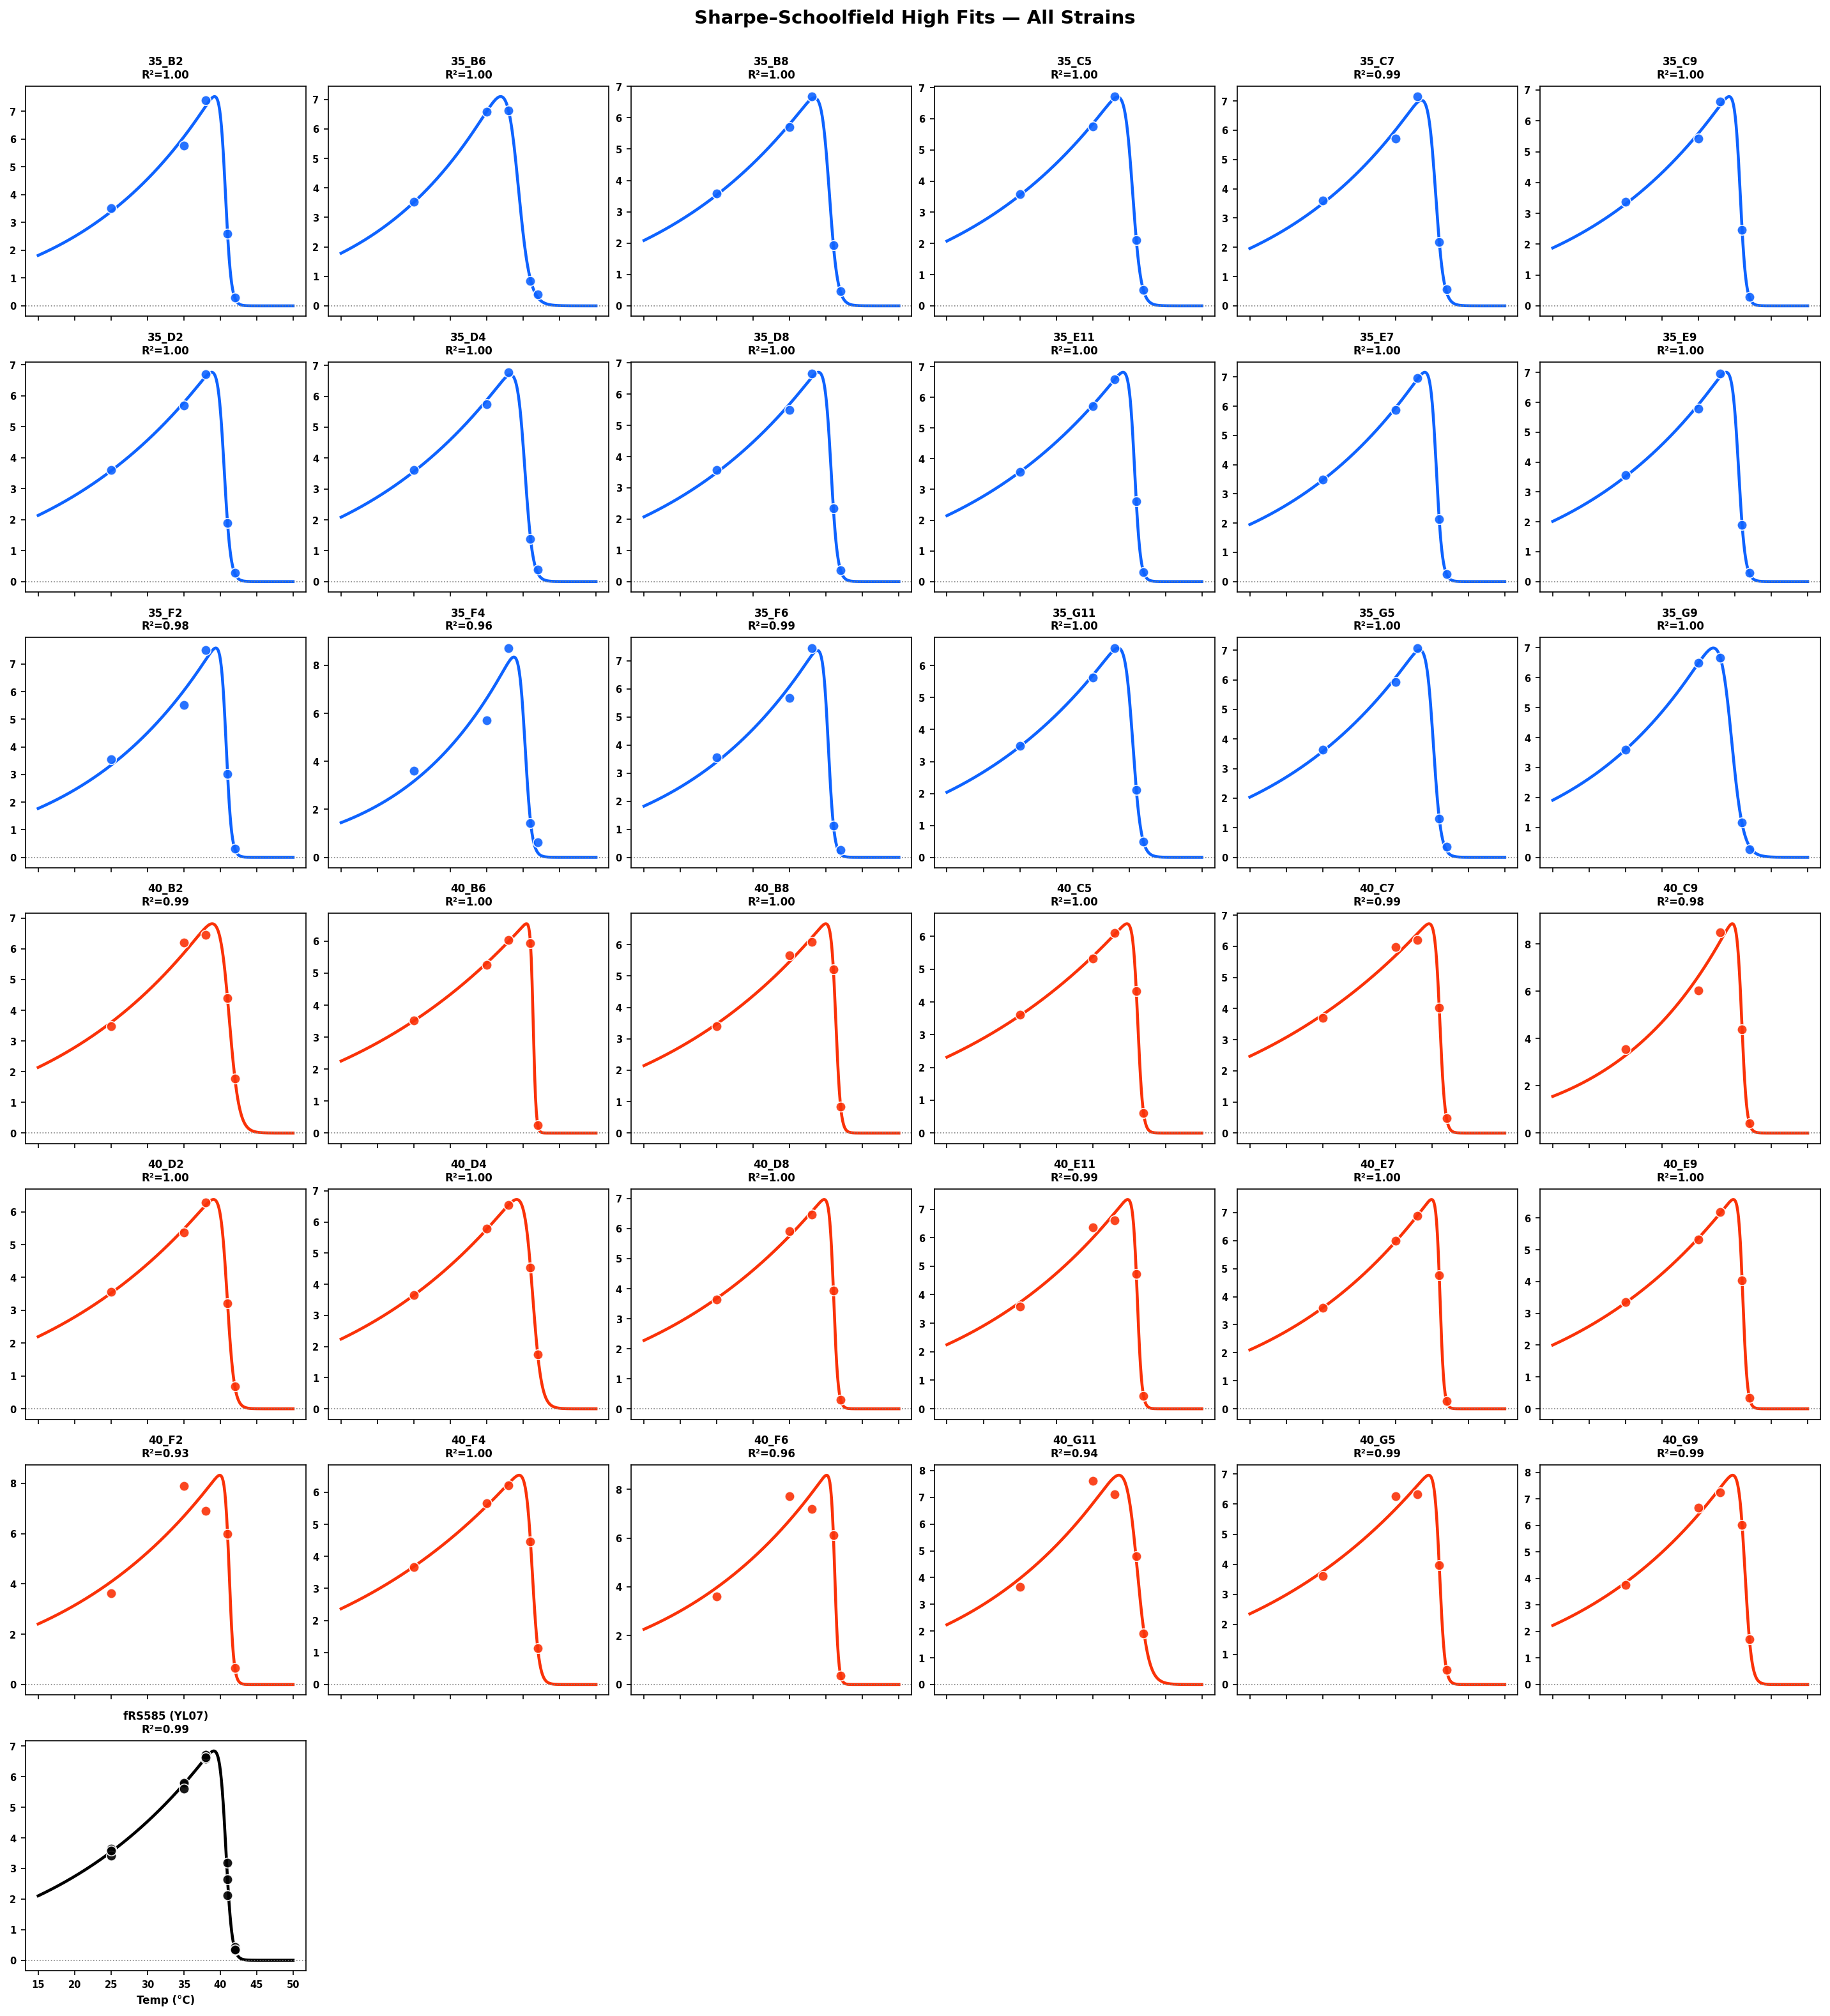

Saved: Processed_Outputs/fig_ssh_all_strains.png


In [35]:
PRIMARY_GROUPS = ['35°C Evolved', '40°C Evolved', 'Ancestor']

def plot_ssh_grid(strain_subset, filename, title):
    n     = len(strain_subset)
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*3),
                              sharex=True, sharey=False)
    axes_flat = axes.flatten()
    for i, (_, row) in enumerate(strain_subset.iterrows()):
        ax    = axes_flat[i]
        sid   = row['strain']
        color = EVO_COLORS.get(row['evo_history'], '#AAAAAA')
        is_bad= sid in bad_strains
        obs   = mu_mean[mu_mean['strain']==sid]
        pred  = tpc_preds[tpc_preds['strain']==sid]
        ax.scatter(obs['temp'], obs['mu'], color=color, s=55, zorder=5,
                   alpha=0.9, edgecolors='white', linewidths=0.8)
        ax.plot(pred['temp'], pred['pred'].clip(lower=-2), color=color,
                lw=1.5 if is_bad else 2.2, ls='--' if is_bad else '-')
        ax.axhline(0, color='grey', lw=0.8, ls=':')
        ax.set_title(f"{sid}\nR²={row['r2']:.2f}{' ⚠' if is_bad else ''}",
                     fontsize=8, fontweight='bold')
        ax.tick_params(labelsize=7, width=0.8)
    for ax in axes_flat[n:]:
        ax.set_visible(False)
    for ax in axes_flat[max(0,(nrows-1)*ncols):n]:
        ax.set_xlabel('Temp (°C)', fontsize=8, fontweight='bold')
    fig.suptitle(title, fontweight='bold', fontsize=14, y=1.0)
    plt.tight_layout(h_pad=0.8, w_pad=0.5)
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show(); print(f'Saved: {filename}')

#All strains
plot_ssh_grid(tpc_params,
             OUT / 'fig_ssh_all_strains.png',
             'Sharpe–Schoolfield High Fits — All Strains')

## TPCs

Thin lines = individual strain fits. Thick lines = group mean
SSH curve (mean of per-strain parameters). Dots = observed per-well growth rates.

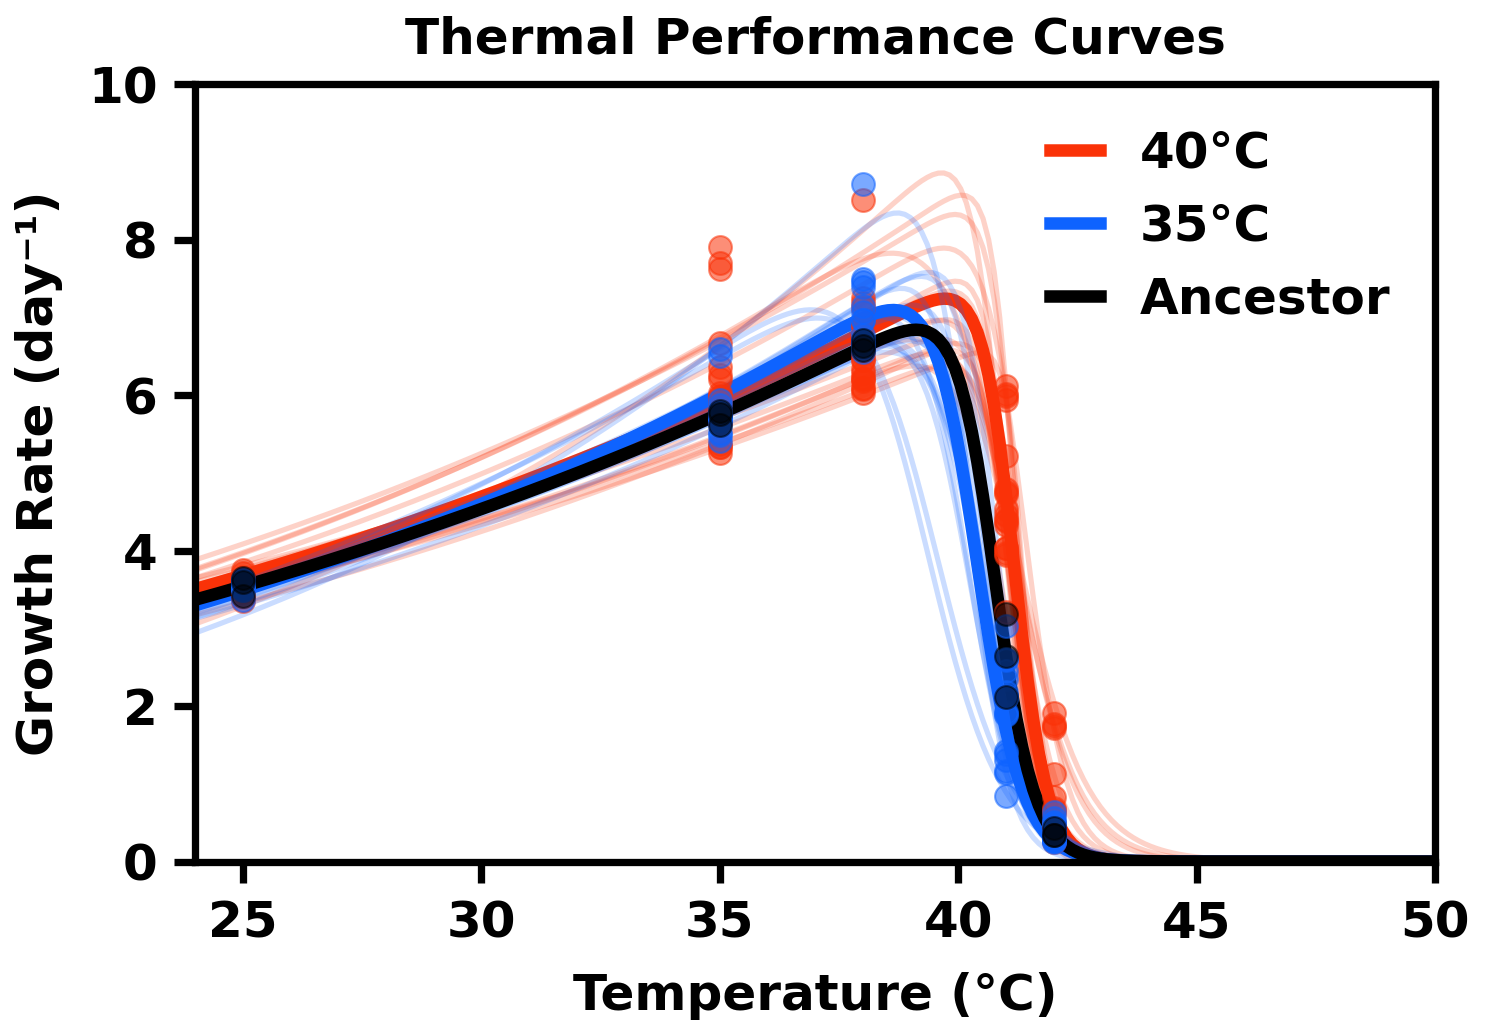

Saved: fig1b_overlay_primary.png


In [40]:
LEGEND_LABELS = {
    '40°C Evolved': '40°C',
    '35°C Evolved': '35°C',
    'Ancestor':     'Ancestor',
}

fig, ax = plt.subplots(figsize=(10, 7))

for evo in ['40°C Evolved', '35°C Evolved', 'Ancestor']:
    if evo not in tpc_preds['evo_history'].values: continue
    color   = EVO_COLORS.get(evo, '#AAAAAA')
    clean_s = tpc_params_clean[tpc_params_clean['evo_history']==evo]['strain'].values

    # Individual strain curves
    for sid, sg in tpc_preds[tpc_preds['evo_history']==evo].groupby('strain'):
        if sid not in clean_s: continue
        pv = sg['pred'].values.copy(); pv[pv<0] = np.nan
        ax.plot(sg['temp'], pv, color=color, alpha=0.22, lw=2.5)

    # Group mean curve
    gp = tpc_params_clean[tpc_params_clean['evo_history']==evo]
    if len(gp):
        mp = gp[['r_tref','e','eh','th']].mean().values
        pm = sharpeschoolhigh(T_pred, *mp); pm[pm<0] = np.nan
        ax.plot(T_pred, pm, color=color, lw=6.0, label=LEGEND_LABELS.get(evo, evo))

    # Observed data points
    obs = mu_mean[mu_mean['evo_history']==evo]
    ax.scatter(obs['temp'], obs['mu'], color=color, s=120, alpha=0.55, zorder=4)

ax.set_xlabel('Temperature (°C)', fontsize=24, fontweight='bold', labelpad=12)
ax.set_ylabel('Growth Rate (day⁻¹)', fontsize=24, fontweight='bold', labelpad=12)
ax.set_title('Thermal Performance Curves', fontsize=24, fontweight='bold', pad=15)
ax.set_xlim(24, 50); ax.set_ylim(0, 10.0)
ax.tick_params(axis='both', labelsize=24, width=3.5, length=10, pad=8)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_linewidth(3.5)
ax.legend(frameon=False, fontsize=24, handlelength=1.0,
          loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig(OUT / 'fig1b_overlay_primary.png', bbox_inches='tight', dpi=300)
plt.show(); print('Saved: fig1b_overlay_primary.png')

## Linear mixed-effects model

Tests whether evolution history and test temperature interact to predict growth rate.

In [60]:
gr_lme = growth_rates[growth_rates['evo_history'].isin(['35°C Evolved','40°C Evolved','Ancestor'])].copy()
gr_lme['temp_fac'] = gr_lme['temp'].astype(str)

lme_model = smf.mixedlm(
    'mu ~ C(evo_history, Treatment("35°C Evolved")) * C(temp_fac, Treatment("25"))',
    data=gr_lme, groups=gr_lme['strain'], re_formula='~1'
).fit(reml=True, method='lbfgs')

wald = lme_model.wald_test_terms(scalar=True)
wald_df = wald.summary_frame()
wald_df.index = ['Intercept','evolution_history','test_temperature',
                 'evolution_history : test_temperature'][:len(wald_df)]
wald_df.columns = ['Chi2','P-value','df']
wald_df['Sig.'] = wald_df['P-value'].apply(
    lambda p: '****' if p<0.0001 else'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')

print('TYPE III WALD χ² TESTS')
print(wald_df[['df','Chi2','P-value','Sig.']].round({'Chi2':3,'P-value':6}).to_string())

p_int = wald_df.loc['evolution_history : test_temperature','P-value']
print(f'\nInteraction p = {p_int:.2e}')

TYPE III WALD χ² TESTS
                                      df      Chi2   P-value  Sig.
Intercept                              1   831.126  0.000000  ****
evolution_history                      2     0.033  0.983842    ns
test_temperature                       4  2324.122  0.000000  ****
evolution_history : test_temperature   8   244.994  0.000000  ****

Interaction p = 1.98e-48


## Topt vs Thermal Performance Retention

Thermal Performance Retention (TPR) = growth at 41°C / growth at 38°C.
Higher values indicate better performance retention near the thermal limit.

Pearson's r quantifies the relationship between Topt and TPR across all strains.

Pearson r = 0.801, p = 0.0000


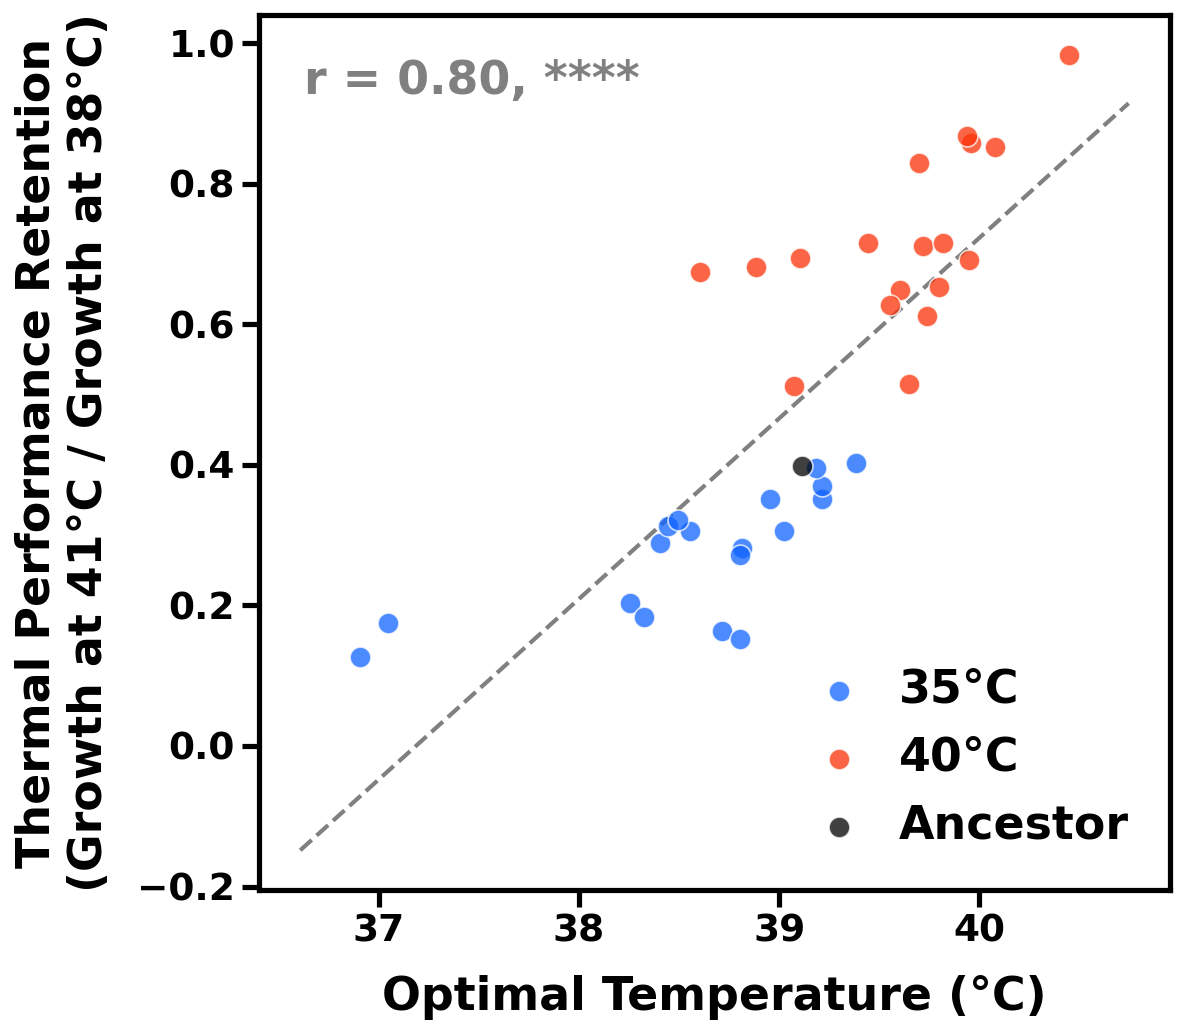

Saved: fig_topt_vs_tpr.png


In [53]:
from scipy.stats import pearsonr

# Compute TPR per strain
tpr = (
    mu_mean[
        mu_mean['evo_history'].isin(PRIMARY_GROUPS) &
        mu_mean['temp'].isin([38, 41]) &
        ~mu_mean['strain'].isin(bad_strains)
    ]
    .groupby(['strain','evo_history','temp'])['mu'].mean().reset_index()
    .pivot_table(index=['strain','evo_history'], columns='temp', values='mu')
    .reset_index()
)
tpr.columns = ['strain','evo_history','growth_38C','growth_41C']
tpr['TPR'] = tpr['growth_41C'] / tpr['growth_38C']

# Merge with Topt
scatter_df = (
    tpc_params_clean[tpc_params_clean['evo_history'].isin(PRIMARY_GROUPS)]
    [['strain','evo_history','topt']]
    .merge(tpr[['strain','TPR']], on='strain')
)

r_p, p_p = pearsonr(scatter_df['topt'], scatter_df['TPR'])
print(f'Pearson r = {r_p:.3f}, p = {p_p:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

for evo, grp in scatter_df.groupby('evo_history'):
    ax.scatter(grp['topt'], grp['TPR'],
               color=EVO_COLORS.get(evo,'#AAAAAA'), s=100, alpha=0.75,
               zorder=4, edgecolors='white', linewidths=0.8,
               label={'40°C Evolved':'40°C','35°C Evolved':'35°C',
                      'Ancestor':'Ancestor'}.get(evo, evo))

# Regression line
x = scatter_df['topt'].values; y = scatter_df['TPR'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min()-0.3, x.max()+0.3, 200)
ax.plot(x_line, m*x_line+b, color='grey', lw=2.0, ls='--', zorder=3)

sig = '****' if p_p<0.0001 else '***' if p_p<0.001 else '**' if p_p<0.01 else '*' if p_p<0.05 else 'ns'
ax.text(0.05, 0.95, f'r = {r_p:.2f}, {sig}', transform=ax.transAxes,
        fontsize=22, fontweight='bold', va='top', ha='left', color='grey')

ax.set_xlabel('Optimal Temperature (°C)', fontsize=22, fontweight='bold', labelpad=12)
ax.set_ylabel('Thermal Performance Retention\n(Growth at 41°C / Growth at 38°C)',
              fontsize=22, fontweight='bold', labelpad=12)
ax.tick_params(axis='both', labelsize=18, width=2.5, length=8)
for lbl in ax.get_xticklabels() + ax.get_yticklabels(): lbl.set_fontweight('bold')
for spine in ax.spines.values(): spine.set_linewidth(2.5)
ax.legend(frameon=False, fontsize=22, handlelength=1.0)

plt.tight_layout()
plt.savefig(OUT / 'fig_topt_vs_tpr.png', bbox_inches='tight', dpi=300)
plt.show(); print('Saved: fig_topt_vs_tpr.png')

## Export CSVs

In [56]:
# Per-strain Topt and CTmax
(
    tpc_params_clean[tpc_params_clean['evo_history'].isin(PRIMARY_GROUPS)]
    [['strain','evo_history','topt','ctmax']]
    .sort_values(['evo_history','strain'])
    .rename(columns={'topt':'T_opt_C','ctmax':'CT_max_C'})
    .to_csv(OUT / 'prism_topt_ctmax_per_strain.csv', index=False)
)

# Growth rates at 41C and 42C (per-strain means)
prism_hot = (
    growth_rates[
        growth_rates['evo_history'].isin(PRIMARY_GROUPS) &
        growth_rates['temp'].isin([41,42]) &
        ~growth_rates['strain'].isin(bad_strains)
    ]
    .groupby(['strain','evo_history','temp'])['mu'].mean().reset_index()
    .pivot_table(index=['strain','evo_history'], columns='temp', values='mu')
    .reset_index()
)
prism_hot.columns = ['strain','evo_history','growth_41C','growth_42C']
prism_hot.to_csv(OUT / 'prism_growth_41_42_per_strain.csv', index=False)

# Observed growth rates (temperature as rows, strain as columns)
(
    mu_mean[mu_mean['evo_history'].isin(PRIMARY_GROUPS)]
    .groupby(['strain','temp'])['mu'].mean()
    .unstack(level='strain')
    .reset_index()
    .rename(columns={'temp':'Temperature_C'})
    .to_csv(OUT / 'prism_observed_growth_rates.csv', index=False)
)

# Fitted TPC curves (temperature as rows, strain as columns)
(
    tpc_preds[
        tpc_preds['evo_history'].isin(PRIMARY_GROUPS) &
        ~tpc_preds['strain'].isin(bad_strains)
    ]
    .pivot_table(index='temp', columns='strain', values='pred')
    .reset_index()
    .to_csv(OUT / 'prism_tpc_curves.csv', index=False)
)

# Thermal Performance Retention per strain
tpr[['strain','evo_history','TPR']].to_csv(
    OUT / 'prism_thermal_performance_retention.csv', index=False)

# Full SSH parameters per strain
tpc_params.to_csv(OUT / 'tpc_params_ssh.csv', index=False)

print(f'Exported to {OUT}/')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name}')

Exported to Processed_Outputs/
  fig1b_overlay_primary.png
  fig_ssh_all_strains.png
  fig_ssh_primary_strains.png
  fig_topt_vs_tpr.png
  prism_growth_41_42_per_strain.csv
  prism_observed_growth_rates.csv
  prism_thermal_performance_retention.csv
  prism_topt_ctmax_per_strain.csv
  prism_tpc_curves.csv
  qc_raw_curves.png
  tpc_params_ssh.csv
